# OCR Model Training using Donut (Document Understanding Transformer)



In [13]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
!pip install -q transformers datasets Pillow jiwer nbformat
!pip install -q accelerate evaluate


In [ ]:
import os
from glob import glob
import re

dataset_dir = 'simulated-sources'

def build_dataset_pairs(base_dir):
    image_paths = glob(os.path.join(base_dir, '**', '*.png'), recursive=True)
    pairs = []
    missing_gt = 0
    
    for img_path in image_paths:
        # Strip suffix "-simulated-..."
        base_name = img_path.rsplit('.png', 1)[0]
        base_name = re.sub(r'-simulated-\d+dpi$', '', base_name)
        
        gt_path = base_name + '.gt.txt'
        
        if os.path.exists(gt_path):
            with open(gt_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()
            # If text is not completely empty, append
            if text:
                pairs.append({"image": img_path, "text": text})
        else:
            missing_gt += 1
            
    print(f"Found {len(pairs)} valid image-text pairs.")
    print(f"Could not find ground truth for {missing_gt} images.")
    return pairs

if not os.path.exists(dataset_dir):
    print(f"WARNING: Directory {dataset_dir} does not exist! Please check Kaggle Input path.")
else:
    all_pairs = build_dataset_pairs(dataset_dir)


Found 2970 valid image-text pairs.
Could not find ground truth for 0 images.


In [15]:
from transformers import DonutProcessor
from datasets import Dataset
import random
from PIL import Image

# Shuffle and subset only 5% of data
random.seed(42)
random.shuffle(all_pairs)

# Limit to 5%
subset_idx = int(len(all_pairs) * 0.05)
subset_pairs = all_pairs[:subset_idx]

# Split 90-10 on the 5% subset
split_idx = int(len(subset_pairs) * 0.9)
train_pairs = subset_pairs[:split_idx]
val_pairs = subset_pairs[split_idx:]

train_dataset = Dataset.from_list(train_pairs)
val_dataset = Dataset.from_list(val_pairs)

model_id = "naver-clova-ix/donut-base"
processor = DonutProcessor.from_pretrained(model_id)
# Ensure the <s_text> token is properly added if missing
if "<s_text>" not in processor.tokenizer.get_vocab():
    processor.tokenizer.add_special_tokens({"additional_special_tokens": ["<s_text>", "</s_text>"]})

task_prompt = "<s_text>"

def preprocess_function(examples):
    images = [Image.open(img_path).convert("RGB") for img_path in examples["image"]]
    texts = examples["text"]
    
    # Preprocess images
    pixel_values = processor(images, return_tensors="pt").pixel_values
    
    # Preprocess targets
    target_sequences = [task_prompt + t + "</s_text>" for t in texts]
    labels = processor.tokenizer(
        target_sequences, 
        padding="max_length", 
        max_length=512, # Document length can be long, tune this between 512, 1024
        truncation=True, 
        return_tensors="pt"
    ).input_ids
    
    # Ignore pad tokens for loss calculation
    labels[labels == processor.tokenizer.pad_token_id] = -100
    
    return {"pixel_values": pixel_values, "labels": labels}

train_ds = train_dataset.map(preprocess_function, batched=True, batch_size=1, remove_columns=["image", "text"])
val_ds = val_dataset.map(preprocess_function, batched=True, batch_size=1, remove_columns=["image", "text"])


Map:   0%|          | 0/133 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

In [16]:
import torch
from transformers import VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"


model = VisionEncoderDecoderModel.from_pretrained(model_id)

# FREEZE ENCODER TO SAVE VRAM
for param in model.encoder.parameters():
    param.requires_grad = False


# Resize token embeddings in case we added new special tokens
model.decoder.resize_token_embeddings(len(processor.tokenizer))

# Model configuration
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.generation_config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_text>'])[0]
model.generation_config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_text>'])[0]
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = processor.tokenizer.eos_token_id
model.generation_config.max_length = 512
model.generation_config.early_stopping = False
model.generation_config.no_repeat_ngram_size = 3

model.to(device)
print(f"Model loaded on {device}")


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded on cuda


In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer
import evaluate
import numpy as np

cer_metric = evaluate.load("cer")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Replace -100 with pad token
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)
    
    # Process predictions as well to avoid OverflowError with -100
    predictions = np.where(predictions != -100, predictions, processor.tokenizer.pad_token_id)
    decoded_preds = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Calculate CER
    cer = cer_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"cer": cer}

training_args = Seq2SeqTrainingArguments(
    output_dir="./donut_ocr_output",
    predict_with_generate=True,
    eval_strategy="steps",     
    save_strategy="steps",
    eval_steps=12,
    save_steps=12,
    logging_steps=50,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    learning_rate=2e-5,
    max_steps=118,
    fp16=True if torch.cuda.is_available() else False,
    report_to="none",
    gradient_checkpointing=True,
    gradient_accumulation_steps=4,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)


In [18]:
trainer.train()

Step,Training Loss,Validation Loss,Cer
12,No log,0.434426,0.918493
24,No log,0.184229,0.407268
36,No log,0.122618,1.000000
48,No log,0.091008,0.017656
60,3.779554,0.082214,0.050038
72,3.779554,0.074222,0.201180
84,3.779554,0.069533,0.264041
96,3.779554,0.066818,0.252055
108,0.424143,0.065227,0.252131


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=118, training_loss=1.8311209638239974, metrics={'train_runtime': 5786.2956, 'train_samples_per_second': 0.082, 'train_steps_per_second': 0.02, 'total_flos': 5.791040377690522e+18, 'train_loss': 1.8311209638239974, 'epoch': 3.481203007518797})

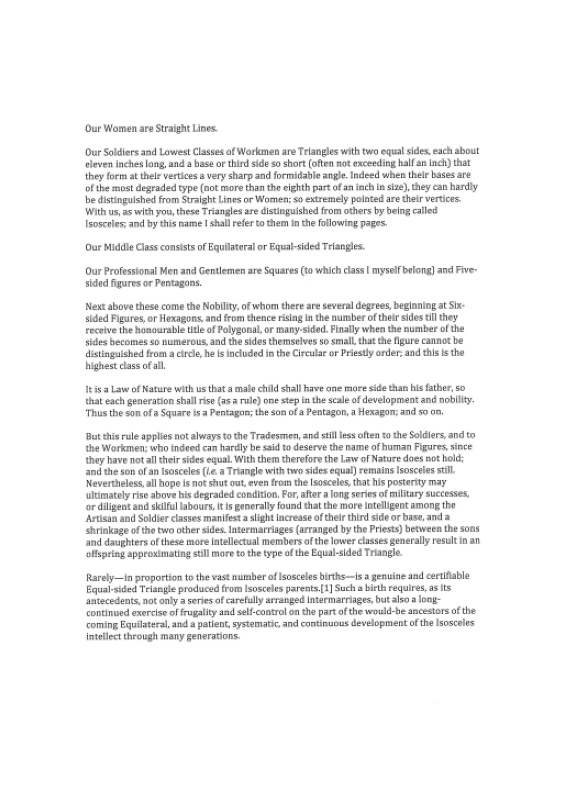

=== GROUND TRUTH ===
Our Women are Straight Lines.
Our Soldiers and Lowest Classes of Workmen are Triangles with two equal sides, each about
eleven inches long, and a base or third side so short (often not exceeding half an inch) that
they form at their vertices a very sharp and formidable angle. Indeed when their bases are
of the most degraded type (not more than the eighth part of an inch in size), they can hardly
be distinguished from Straight Lines or Women; so extremely pointed are their vertices.
With us, as w...

=== PREDICTION ===
<s><s></s>...


In [21]:
import matplotlib.pyplot as plt

def infer_sample(idx):
    sample = val_pairs[idx]
    image = Image.open(sample['image']).convert('RGB')
    
    pixel_values = processor(image, return_tensors="pt").pixel_values
    
    task_prompt = "<s_text>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt")["input_ids"]
    
    outputs = model.generate(
        pixel_values.to(device),
        decoder_input_ids=decoder_input_ids.to(device),
        max_length=model.decoder.config.max_position_embeddings,
        early_stopping=False,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=1,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
    
    prediction = processor.batch_decode(outputs.sequences)[0]
    prediction = prediction.replace("<s_text>","").replace("</s_text>","").strip()
    
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    
    print("=== GROUND TRUTH ===")
    print(sample['text'][:500] + "...") # Limit output length
    print("\n=== PREDICTION ===")
    print(prediction[:500] + "...")

# Run inference on the first validation sample
infer_sample(0)